### **Download dataset**

In [ ]:
# @title
# =========================================================
# DOWNLOAD DATASET ZIP TỪ GOOGLE DRIVE
# =========================================================
!gdown --id 1F6v_16H3PQgXaibGLJCV07WmA1JwkUP-

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -q BTXRD_FS.zip

# =========================================================
# KIỂM TRA DATASET
# =========================================================
print("\nDATASET STRUCTURE:")
!ls BTXRD_FS

# =========================================================
# COPY DATASET VÀO PROJECT
# =========================================================
# !mv BTXRD_FS content/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1F6v_16H3PQgXaibGLJCV07WmA1JwkUP-
From (redirected): https://drive.google.com/uc?id=1F6v_16H3PQgXaibGLJCV07WmA1JwkUP-&confirm=t&uuid=9c90f924-115e-40da-bd80-27127232a11e
To: /content/BTXRD_FS.zip
100% 3.59G/3.59G [00:38<00:00, 94.4MB/s]

DATASET STRUCTURE:
dataset.xlsx  images


### **Import & Install**

In [ ]:
# @title
# Cài đặt các thư viện cần thiết
!pip install openpyxl torchmetrics -q

import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 8.1 MB/s eta 0:00:00
Đang sử dụng thiết bị: cpu


### **Dataloader**

In [ ]:
# @title
# Cấu hình đường dẫn
DATA_DIR = '/content/BTXRD_FS'
IMAGES_DIR = os.path.join(DATA_DIR, 'images')
EXCEL_PATH = os.path.join(DATA_DIR, 'dataset.xlsx')

# 1. Đọc file Excel và xử lý tên ảnh
df = pd.read_excel(EXCEL_PATH)
# Đổi đuôi .jpeg thành .png trong cột image_id
df['image_id'] = df['image_id'].str.replace('.jpeg', '.png', regex=False)
df['image_id'] = df['image_id'].str.replace('.jpg', '.png', regex=False)

# 2. Chia tập dữ liệu (80% Train, 10% Val, 10% Test)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['tumor'])
val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=42, stratify=val_df['tumor'])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Số lượng tập Train: {len(train_df)}")
print(f"Số lượng tập Val: {len(val_df)}")
print(f"Số lượng tập Test: {len(test_df)}")

# 3. Định nghĩa Dataset class
class BTXRDDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, 'image_id']
        img_path = os.path.join(self.img_dir, img_name)

        # Mở ảnh và chuyển về RGB
        image = Image.open(img_path).convert('RGB')

        # Nhãn u xương (tumor)
        label = float(self.dataframe.loc[idx, 'tumor'])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor([label], dtype=torch.float32)

# 4. Data Augmentation & Transforms theo thiết lập
# EfficientNet-B3 thường dùng kích thước ảnh 300x300
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(p=0.5), # Lật ngang
    transforms.RandomRotation(degrees=15),  # Xoay ngẫu nhiên 15 độ
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = val_transform

# 5. Tạo DataLoader (Batch size = 16)
BATCH_SIZE = 16
train_dataset = BTXRDDataset(train_df, IMAGES_DIR, transform=train_transform)
val_dataset = BTXRDDataset(val_df, IMAGES_DIR, transform=val_transform)
test_dataset = BTXRDDataset(test_df, IMAGES_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Số lượng tập Train: 2996
Số lượng tập Val: 375
Số lượng tập Test: 375


### **Train**

In [ ]:
# @title
import torch
import torch.nn as nn
from torchvision import models
import os

# --- 1. CẤU HÌNH SIÊU THAM SỐ ---
Lr1 = 1e-4        # LR cho giai đoạn Transfer learning
Lr2 = 1e-5      # LR cho giai đoạn Finetune
EPOCHS = 25       # Số epoch chạy Transfer learning
TOTAL_EPOCHS = 100      # Tổng số epoch dự kiến
PATIENCE = 15           # Early stopping
SAVE_PATH = '/content/checkpoint/best_efficientnet_b3.pth'
SAVE_DIR = '/content/checkpoint'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 2. KHỞI TẠO MÔ HÌNH ---
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1) # Phân loại nhị phân (tumor/non-tumor)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

# --- 3. LỚP HỖ TRỢ EARLY STOPPING ---
class EarlyStopping:
    def __init__(self, patience=10, path='model.pth'):
        self.patience = patience
        self.best_acc = None
        self.counter = 0
        self.path = path
        self.early_stop = False

    def __call__(self, val_acc, model):
        if self.best_acc is None:
            self.best_acc = val_acc
            self.save_checkpoint(model)
        elif val_acc < self.best_acc:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_acc = val_acc
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

early_stopping = EarlyStopping(patience=PATIENCE, path=SAVE_PATH)

# --- 4. HÀM HUẤN LUYỆN CHO 1 EPOCH ---
def run_epoch(epoch, model, loader, optimizer, criterion, is_train=True):
    if is_train:
        model.train()
        # Ép riêng các tầng Norm đóng băng Running Mean/Variance (Giống hệt Keras)
        for m in model.modules():
            if isinstance(m, (nn.BatchNorm2d, nn.GroupNorm, nn.LayerNorm)):
                m.eval()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).float()

            if is_train:
                optimizer.zero_grad()

            outputs = model(images).view(-1)
            labels = labels.view(-1)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)

            # ACCURACY (binary classification)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader.dataset)
    acc = correct / total

    return avg_loss, acc


# --- 5. BẮT ĐẦU HUẤN LUYỆN ---
# GIAI ĐOẠN 1: FREEZE BACKBONE (Warmup)
print(f"--- GIAI ĐOẠN 1: FREEZE BACKBONE ({EPOCHS} Epochs) ---")
for param in model.features.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=Lr1)

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(epoch, model, train_loader, optimizer, criterion, is_train=True)
    val_loss, val_acc = run_epoch(epoch, model, val_loader, None, criterion, is_train=False)
    print(f"Epoch {epoch+1}: Train_loss={train_loss:.2f} | Val_loss={val_loss:.2f} | Train_acc={train_acc:.2f} | Val_acc={val_acc:.2f}")
    early_stopping(val_acc, model)
    if early_stopping.early_stop:
        print("Kích hoạt Early Stopping!")
        break

# GIAI ĐOẠN 2: UNFREEZE ALL (Finetuning)
print(f"\n--- GIAI ĐOẠN 2: UNFREEZE ALL & FINETUNE ---")
if not early_stopping.early_stop:
    for param in model.parameters():
        param.requires_grad = True

    # Khóa riêng các tham số của tầng Batch Normalization (Mô phỏng Keras)
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm2d, nn.GroupNorm, nn.LayerNorm)):
            for param in module.parameters():
                param.requires_grad = False

    # Khởi tạo lại optimizer và scheduler cho toàn bộ mô hình
    optimizer = torch.optim.AdamW(model.parameters(), lr=Lr2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(TOTAL_EPOCHS - EPOCHS))

    FINETUNE_EPOCHS = TOTAL_EPOCHS - EPOCHS
    for epoch in range(FINETUNE_EPOCHS):
        train_loss, train_acc = run_epoch(epoch, model, train_loader, optimizer, criterion, is_train=True)
        val_loss, val_acc = run_epoch(epoch, model, val_loader, None, criterion, is_train=False)
        scheduler.step()

        print(f"Epoch {epoch+1}/{FINETUNE_EPOCHS}: Train_loss={train_loss:.2f} | Val_loss={val_loss:.2f} | Train_acc={train_acc:.2f} | Val_acc={val_acc:.2f}")

        early_stopping(val_acc, model)
        if early_stopping.early_stop:
            print("Kích hoạt Early Stopping!")
            break

print("Hoàn thành huấn luyện. Mô hình tốt nhất đã được lưu!")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 128MB/s]


--- GIAI ĐOẠN 1: FREEZE BACKBONE (25 Epochs) ---
Epoch 1: Train_loss=0.68 | Val_loss=0.67 | Train_acc=0.56 | Val_acc=0.65
Epoch 2: Train_loss=0.66 | Val_loss=0.65 | Train_acc=0.65 | Val_acc=0.70
Epoch 3: Train_loss=0.64 | Val_loss=0.63 | Train_acc=0.69 | Val_acc=0.73
Epoch 4: Train_loss=0.62 | Val_loss=0.61 | Train_acc=0.70 | Val_acc=0.73
Epoch 5: Train_loss=0.61 | Val_loss=0.60 | Train_acc=0.71 | Val_acc=0.72
Epoch 6: Train_loss=0.60 | Val_loss=0.59 | Train_acc=0.72 | Val_acc=0.73
Epoch 7: Train_loss=0.59 | Val_loss=0.58 | Train_acc=0.72 | Val_acc=0.74
Epoch 8: Train_loss=0.58 | Val_loss=0.58 | Train_acc=0.73 | Val_acc=0.74
Epoch 9: Train_loss=0.58 | Val_loss=0.57 | Train_acc=0.72 | Val_acc=0.73
Epoch 10: Train_loss=0.58 | Val_loss=0.56 | Train_acc=0.72 | Val_acc=0.73
Epoch 11: Train_loss=0.57 | Val_loss=0.56 | Train_acc=0.73 | Val_acc=0.74
Epoch 12: Train_loss=0.57 | Val_loss=0.56 | Train_acc=0.73 | Val_acc=0.73
Epoch 13: Train_loss=0.56 | Val_loss=0.55 | Train_acc=0.73 | Val_acc=0.7

### **Test**


Bắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...
--------------------------------------------------
KẾT QUẢ ĐÁNH GIÁ Y KHOA (EFFICIENTNETB3):
1. Top-1 Accuracy (Độ chính xác) : 85.60%
2. AUC-ROC Score                  : 0.9258
3. Precision (Giá trị dự báo (+)) : 91.30%
4. Specificity (Độ đặc hiệu)      : 92.55%  (Khả năng loại trừ KHÔNG BỆNH)
5. Recall / Sensitivity (Độ nhạy) : 78.61%  (Khả năng phát hiện BỆNH)
6. Số lượng tham số mạng          : 10,697,769
7. Dung lượng file trọng số (.pth): 41.35 MB
--------------------------------------------------
Bổ sung chỉ số NPV (Dự báo (-))   : 81.31%
--------------------------------------------------


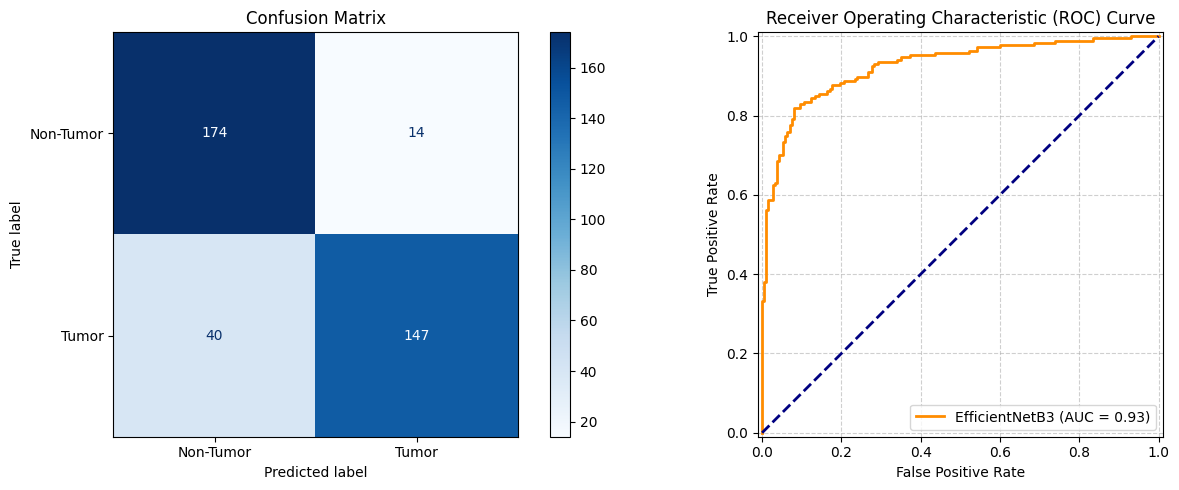

In [ ]:
# @title
# =========================================================
# 6. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST THEO TIÊU CHUẨN Y KHOA
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    accuracy_score
)
import torch
import os

print("\nBắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...")

# 1. Khởi tạo lại cấu trúc mô hình và nạp trọng số PyTorch (.pth)
model = models.efficientnet_b3(weights=None) # Không cần tải lại weights gốc ImageNet
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)
model = model.to(device)

best_model_path = '/content/checkpoint/best_efficientnet_b3.pth'
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location='cpu'))
    file_suffix = "(.pth)"
    model_size_bytes = os.path.getsize(best_model_path)
    model_size_mb = model_size_bytes / (1024 * 1024)
else:
    file_suffix = "(Chưa lưu checkpoint)"
    model_size_mb = 0.0

model.eval()

# 2. Thu thập xác xuất và nhãn thực tế từ test_loader
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float()

        # Ép phẳng về mảng 1 chiều ngay từ đầu
        outputs = model(images).view(-1)
        labels = labels.view(-1)

        # Tính xác suất bằng Sigmoid
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Chuyển đổi sang mảng Numpy 1D phục vụ tính toán các chỉ số
y_prob = np.array(all_probs)
y_true = np.array(all_labels).astype(int)
y_pred = (y_prob > 0.5).astype(int) # Ngưỡng phân loại bệnh 50%

# 3. Tính toán Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# 4. Tính toán các chỉ số y tế theo đúng thứ tự yêu cầu
top1_accuracy = accuracy_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0       # Chính là PPV
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0     # Độ đặc hiệu
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0     # Độ nhạy / Recall
npv = tn / (tn + fn) if (tn + fn) > 0 else 0             # Giá trị dự báo âm tính

# Đếm tổng số lượng tham số mạng trong PyTorch
total_params = sum(p.numel() for p in model.parameters())

# --- IN KẾT QUẢ ĐÁNH GIÁ CHI TIẾT THEO ĐÚNG THỨ TỰ CỦA KÉRAS MẪU ---
print("-" * 50)
print(f"KẾT QUẢ ĐÁNH GIÁ Y KHOA (EFFICIENTNETB3):")
print(f"1. Top-1 Accuracy (Độ chính xác) : {top1_accuracy*100:.2f}%")
print(f"2. AUC-ROC Score                  : {auc_score:.4f}")
print(f"3. Precision (Giá trị dự báo (+)) : {precision*100:.2f}%")
print(f"4. Specificity (Độ đặc hiệu)      : {specificity*100:.2f}%  (Khả năng loại trừ KHÔNG BỆNH)")
print(f"5. Recall / Sensitivity (Độ nhạy) : {sensitivity*100:.2f}%  (Khả năng phát hiện BỆNH)")
print(f"6. Số lượng tham số mạng          : {total_params:,}")
print(f"7. Dung lượng file trọng số {file_suffix}: {model_size_mb:.2f} MB")
print("-" * 50)
print(f"Bổ sung chỉ số NPV (Dự báo (-))   : {npv*100:.2f}%")
print("-" * 50)

# 5. TRỰC QUAN HÓA ĐỒ THỊ ĐÔI (CONFUSION MATRIX & ROC CURVE)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Tumor", "Tumor"])
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix")

# Đồ thị 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name='EfficientNetB3')
roc_disp.plot(ax=ax[1], color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường chéo ngẫu nhiên
ax[1].set_title("Receiver Operating Characteristic (ROC) Curve")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download("/content/checkpoint/best_efficientnet_b3.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>